<a href="https://colab.research.google.com/github/timosachsenberg/PyOpenMSCourse/blob/main/notebooks/PyOpenMS_TryOnline_Raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# pyOpenMS Try Online – From Raw File to Peptide Identifications

*A ~10 minute hands-on tour of the [pyOpenMS](https://pyopenms.readthedocs.io/) API. Open this notebook in Google Colab, run the first cell, and you are off.*

pyOpenMS is a Python library that wraps the battle-tested C++ library [OpenMS](https://www.openms.de/). It exposes OpenMS data structures and algorithms (spectrum containers, sequence classes, digest enzymes, search engines, file readers/writers) directly in Python, so a full analysis pipeline can be written and run from a notebook.

This notebook is a **pyOpenMS API tutorial**: it walks through the using `MSExperiment` and `MSSpectrum`, two core pyopenms objects for interacting with raw data as well as some algorithms including the `ProteaseDigestion`, `SimpleSearchEngineAlgorithm` and `TheoreticalSpectrumGenerator` all useful for making a quick peptide identification.

Everything here downloads its own small data files and runs start-to-finish in a couple of minutes.


# Contents

Jump to any section from here. The notebook is grouped by what you run together.

1. **[Setup](#1-setup)**
   1. [Install & import](#1-setup)
   2. [Get a demo dataset](#get-a-demo-dataset)
2. **[Examining the Raw Data](#2-examining-the-raw-data)**
   1. [Look inside the data](#look-inside-the-data)
   2. [Pandas dataframe export](#pandas-dataframe-export)
   3. [Plotting with pyopenms-viz](#plotting-with-pyopenms-viz)
3. **[Generating Theoretical Spectra](#3-generating-theoretical-spectra)**
   1. [Peptide math with `AASequence`](#peptide-math-with-aasequence)
   2. [Digest a protein in-silico](#digest-a-protein-in-silico)
4. **[Identifying the Peptides](#4-identifying-the-peptides)**
   1. [Match with a theoretical spectrum](#match-with-a-theoretical-spectrum)
   2. [Visualize with pyopenms-viz (mirror plot)](#visualize-with-pyopenms-viz-mirror-plot)
5. **[Useful Links](#5-useful-links)**


## 1. Setup

pyOpenMS can be installed from PyPI with pip. We also install **pandas** (to export spectra to DataFrames) and **pyopenms-viz** (interactive spectrum plotting). We then fetch the small **demo dataset** used by every later section.



In [1]:
!pip install -q pyopenms
!pip install -q pandas
!pip install -q "pyopenms-viz>=1.0.0"
!pip install -q plotly

/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found


In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyopenms as oms

%matplotlib inline

print("Python",f"{sys.version.split()[0]}")
print("pyOpenMS", f"{oms.__version__}")
print("numpy", f"{np.__version__}")
print("pandas", f"{pd.__version__}")
print("matplotlib", f"{plt.matplotlib.__version__}")
print("Ready to go!")

Python 3.12.3
pyOpenMS 3.5.0
numpy 2.5.3
pandas 3.0.6
matplotlib 3.11.2
Ready to go!


### Get a demo dataset

The notebook works with a small **demo dataset** so that everything runs quickly and offline. All of these concepts also apply to full size datasets.


In [3]:
import os
from urllib.request import urlretrieve

DATA = "https://raw.githubusercontent.com/timosachsenberg/PyOpenMSCourse/main/data"

files = {
    "UPS1_5min.mzML":        f"{DATA}/UPS1_5min.mzML",       # demo MS data (~36 MB)
    "two_ups_proteins.fasta": f"{DATA}/two_ups_proteins.fasta", # demo protein sequences
    "UPS1_5min.idXML":       f"{DATA}/UPS1_5min.idXML",       # demo identifications
}

for name, url in files.items():
    if not os.path.exists(name):
        print(f"Downloading {name} ...")
        urlretrieve(url, name)
    else:
        print(f"{name} already present")

for name in files:
    size_mb = os.path.getsize(name) / 1e6
    print(f"  {name:<24} {size_mb:8.2f} MB")

UPS1_5min.mzML already present
two_ups_proteins.fasta already present
UPS1_5min.idXML already present
  UPS1_5min.mzML              37.59 MB
  two_ups_proteins.fasta       0.00 MB
  UPS1_5min.idXML              0.04 MB


## 2. Examining the Raw Data

### Look inside the data

The central container in pyOpenMS is **`MSExperiment`** — it holds every spectrum of a run. Each spectrum is an **`MSSpectrum`**, and a run typically contains two kinds:

- **MS1** spectra (level 1): the intact precursor ions.
- **MS2** spectra (level 2): fragment scans of a single precursor; these are what identification uses.

Many pyOpenMS worflows start with loading a file into an `MSExperiment` object, then iterate through its `MSSpectrum` objects.


In [4]:
exp = oms.MSExperiment()
oms.MzMLFile().load("UPS1_5min.mzML", exp)

ms1 = sum(1 for s in exp if s.getMSLevel() == 1)
ms2 = sum(1 for s in exp if s.getMSLevel() == 2)
print(f"Loaded {len(exp)} spectra in total:")
print(f"  MS1 (level 1)         : {ms1}")
print(f"  MS2 (level 2)         : {ms2}")

Loaded 2043 spectra in total:
  MS1 (level 1)         : 156
  MS2 (level 2)         : 1887


Every `MSSpectrum` stores metadata about how it was acquired. An MS2 spectrum also holds **precursors**: one or more `Precursor` objects with the mass and charge of the ion that was fragmented. Reading these is the `getMetaValue` / `getPrecursors` API.

In [5]:
# Pick the first MS2 spectrum and read its acquisition metadata
first_ms2 = next(s for s in exp if s.getMSLevel() == 2)
precursor = first_ms2.getPrecursors()[0]

print("First MS2 spectrum:")
print("  native id        :", first_ms2.getNativeID())
print("  precursor m/z    :", round(precursor.getMZ(), 3))
print("  precursor charge :", precursor.getCharge())
print("  precursor mass   :", round(precursor.getUnchargedMass(), 3), "Da")
print("  number of peaks  :", first_ms2.size())

First MS2 spectrum:
  native id        : controllerType=0 controllerNumber=1 scan=13813
  precursor m/z    : 443.461
  precursor charge : 4
  precursor mass   : 1769.813 Da
  number of peaks  : 509


The actual **peak data** — the m/z and intensity of every peak — comes out through **`get_peaks()`**, which returns two parallel NumPy arrays. This is the raw input every downstream step (searching, plotting, quantification) works on.

In [6]:
# Pull out the peaks of the first MS2 spectrum
mz_arr, int_arr = first_ms2.get_peaks()

print("get_peaks() returns two parallel arrays:")
print(f"  m/z        : {mz_arr[:5]} ...")
print(f"  intensity  : {int_arr[:5]} ...")
print(f"  length     : {len(mz_arr)} peaks (matches first_ms2.size())")

get_peaks() returns two parallel arrays:
  m/z        : [129.1308136  130.01425171 136.13638306 141.10302734 142.03399658] ...
  intensity  : [6005.283   8825.481   2825.6921  6328.864    881.17896] ...
  length     : 509 peaks (matches first_ms2.size())


Precursor charge distribution across all MS2 spectra:
  charge 2+ : 1291
  charge 3+ : 500
  charge 4+ : 94
  charge 5+ : 2


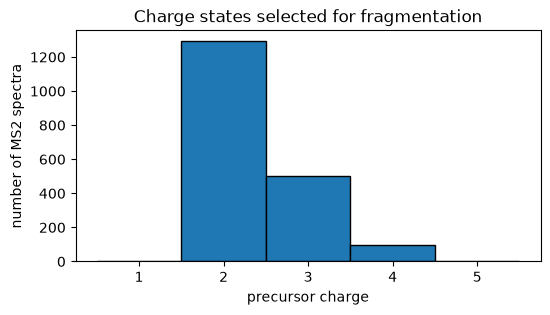

In [7]:
# What charge states were fragmented? A quick histogram.
charges = [s.getPrecursors()[0].getCharge() for s in exp if s.getMSLevel() == 2]
print("Precursor charge distribution across all MS2 spectra:")
for z in sorted(set(charges)):
    print(f"  charge {z}+ : {charges.count(z)}")

plt.figure(figsize=(6, 3))
plt.hist(charges, bins=np.arange(0.5, max(charges) + 1.5, 1), align="mid", edgecolor="black")
plt.xlabel("precursor charge")
plt.ylabel("number of MS2 spectra")
plt.title("Charge states selected for fragmentation")
plt.show()

### Pandas dataframe export

pyOpenMS ships optional **pandas** integration. An **`MSExperiment`** exports all of its peaks into a `DataFrame` with **`get_df()`**. The **`long`** flag controls the shape:

- **`long=True`** — one row *per peak* (columns `RT`, `mz`, `inty`), with the retention time repeated across the rows of each spectrum. Because it is a single flat table, you can filter it straight to one spectrum (for example by `rt`) and plot it directly — no manual flattening of m/z and intensity arrays needed.

- **`long=False`** (the default) — one row *per spectrum*, with `mzarray` and `intarray` holding the full m/z and intensity **arrays** as cells, so each spectrum stays together as one object.

We export both below and compare the two shapes.


In [8]:
# long=True: one row per peak (rt and ms_level repeated across each spectrum)
exp_peaks_df = exp.get_df(long=True)
print("long=True shape:", exp_peaks_df.shape)
exp_peaks_df.head()


long=True shape: (1794744, 4)


,rt,mz,intensity,ms_level
0,2401.687012,350.211884,45417.421875,1
1,2401.687012,350.234680,41089.902344,1
2,2401.687012,350.242035,317741.562500,1
3,2401.687012,351.729492,246831.093750,1
4,2401.687012,352.191406,57769.132812,1


In [9]:
# long=False: one row per spectrum, with the m/z and intensity arrays kept as cells
exp_wide_df = exp.get_df(long=False)
print("long=False shape:", exp_wide_df.shape)
print("columns:", list(exp_wide_df.columns))
exp_wide_df.head()


long=False shape: (2043, 4)
columns: ['rt', 'ms_level', 'mz_array', 'intensity_array']


,rt,ms_level,mz_array,intensity_array
0,2400.2573,2,"[129.1308135986328, 130.01425170898438, 136.13...","[6005.283, 8825.481, 2825.6921, 6328.864, 881...."
1,2400.3868,2,"[129.19908142089844, 130.10459899902344, 133.0...","[2405.6409, 861.1701, 431.31732, 1058.6265, 30..."
2,2400.4910,2,"[136.07106018066406, 141.10107421875, 143.2275...","[245.16933, 299.50443, 320.44116, 1161.0974, 2..."
3,2400.5949,2,"[215.28839111328125, 217.30223083496094, 225.4...","[224.8507, 936.62634, 1360.7781, 1193.5264, 79..."
4,2400.7329,2,"[110.34838104248047, 114.14485168457031, 115.1...","[85.94649, 219.12186, 224.30789, 832.719, 220...."


We can also use `DataFrames` to store metadata in the `MSExperiment` object as shown below. 

In [10]:
# Flatten the whole MSExperiment into a per-spectrum summary table
rows = []
for s in exp:
    row = {
        "native_id": s.getNativeID(),
        "ms_level": s.getMSLevel(),
        "rt": round(s.getRT(), 2),
        "n_peaks": s.size(),
    }
    if s.getPrecursors():
        p = s.getPrecursors()[0]
        row["precursor_mz"] = round(p.getMZ(), 4)
        row["precursor_charge"] = p.getCharge()
    rows.append(row)

exp_df = pd.DataFrame(rows)
print(f"{len(exp_df)} spectra x {len(exp_df.columns)} columns")
exp_df.head()

2043 spectra x 6 columns


,native_id,ms_level,rt,n_peaks,precursor_mz,precursor_charge
0,controllerType=0 controllerNumber=1 scan=13813,2,2400.26,509,443.4605,4.0
1,controllerType=0 controllerNumber=1 scan=13814,2,2400.39,573,457.2902,2.0
2,controllerType=0 controllerNumber=1 scan=13815,2,2400.49,562,478.7805,2.0
3,controllerType=0 controllerNumber=1 scan=13816,2,2400.59,574,741.3299,4.0
4,controllerType=0 controllerNumber=1 scan=13817,2,2400.73,423,367.5142,3.0


### Plotting with pyopenms-viz

[pyopenms-viz](https://pyopenms-viz.readthedocs.io/) adds a **`spectrum` plot kind** to pandas (`backend="ms_matplotlib"`). It is a static figure rendered with matplotlib. Importing `pyopenms_viz` registers the `ms_matplotlib` backend.

In [11]:
import pyopenms_viz  # registers the 'ms_matplotlib' pandas backend

# filter the long-format dataframe to the first MS1 spectrum and plot it
ms1_df = exp_peaks_df[exp_peaks_df.ms_level == 1]
ms1_df = ms1_df[ms1_df.rt == ms1_df.rt.min()]

out = ms1_df.plot(kind="spectrum", x="mz", y="intensity", backend="ms_plotly", annotate_mz=False,
            width=900, height=400, title="MS1 spectrum (plotly)")

In [12]:
# The same works for an MS2 fragment spectrum
ms2_df = exp_peaks_df[exp_peaks_df.ms_level == 2]
ms2_df = ms2_df[ms2_df.rt == ms2_df.rt.min()]
out = ms2_df.plot(kind="spectrum", x="mz", y="intensity", backend="ms_plotly",
            width=900, height=400, title="MS2 spectrum (first MS2 scan)")

## 3. Generating Theoretical Spectra

### Peptide math with `AASequence`

Before searching, it helps to know the core sequence class: **`AASequence`**. It parses a one-letter peptide string, and can compute the things a search engine needs: the **molecular weight** of the peptide, the **m/z of any charge state** (a peptide is ionized by adding protons), and even the full **isotope pattern** via `IsotopeDistribution`.

`getMonoWeight()` gives the mass of the neutral molecule; `getMZ(charge)` adds the charge carriers and divides by the charge.


In [13]:
# Parse a peptide sequence into an AASequence object
pep = oms.AASequence.fromString("GEQIQLKGTVYNYR")
print("Sequence       :", pep.toString())
print("Monoisotopic mass:", round(pep.getMonoWeight(), 4), "Da")
print("Average mass   :", round(pep.getAverageWeight(), 4), "Da")

for z in [1, 2, 3]:
    print(f"  m/z at charge {z}+ : {pep.getMZ(z):8.4f}")

# Charge 2+ is what most MS2 precursors carry: the two extra protons
# raise the mass, and dividing by the charge roughly halves the m/z.
print("\nFormula:", pep.getFormula().toString())

# The isotopic envelope: the monoisotopic peak and its 13C satellites
iso = pep.getFormula().getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(6))
print("\nIsotope distribution (top 6 peaks):")
for c in iso.getContainer():
    print(f"  mass {c.getMZ():8.4f}   probability {c.getIntensity():6.4f}")

Sequence       : GEQIQLKGTVYNYR
Monoisotopic mass: 1667.8631 Da
Average mass   : 1668.8515 Da
  m/z at charge 1+ : 1668.8704
  m/z at charge 2+ : 834.9388
  m/z at charge 3+ : 556.9617

Formula: C74H117N21O23

Isotope distribution (top 6 peaks):
  mass 1667.8631   probability 0.3899
  mass 1668.8665   probability 0.3510
  mass 1669.8698   probability 0.1747
  mass 1670.8732   probability 0.0624
  mass 1671.8765   probability 0.0178
  mass 1672.8799   probability 0.0043


### Digest a protein in-silico

In bottom up proteomics, proteins are digested into peptides before being injected into the mass spectrometer. The most common enzyme used for digestion is **Trypsin** which cleaves after K and R. Therefore when analyzing bottom-up datasets, proteins must be digested into peptides *in-silico*. In pyOpenMS, the **`ProteaseDigestion`** object can be used to perform *in-silico* digestion which is demonstrated below.


In [14]:
entries = []
oms.FASTAFile().load("two_ups_proteins.fasta", entries)
print(f"Loaded {len(entries)} protein(s):")
for e in entries:
    print(f"  {e.identifier}  ({len(e.sequence)} aa)")

Loaded 2 protein(s):
  sp|P01031|CO5_HUMAN  (1676 aa)
  sp|P01133|EGF_HUMAN  (1207 aa)


In [15]:
dig = oms.ProteaseDigestion()
dig.setEnzyme("Trypsin")

protein = oms.AASequence(entries[0].sequence)
result = []
dig.digest(protein, result, 7, 40)

print(f"Trypsin digest of {entries[0].identifier} -> {len(result)} peptides")
for pep in result[:8]:
    print("   ", pep.toString())
print("    ...")

Trypsin digest of sp|P01031|CO5_HUMAN -> 88 peptides
    MGLLGILCFLIFLGK
    TWGQEQTYVISAPK
    VGASENIVIQVYGYTEAFDATISIK
    FSYSSGHVHLSSENK
    FQNSAILTIQPK
    QLPGGQNPVSYVYLEVVSK
    MPITYDNGFLFIHTDKPVYTPDQSVK
    VYSLNDDLKPAK
    ...


Trypsin sometimes *misses* a cleavage site, leaving two neighbouring peptides joined. `ProteaseDigestion` lets you control this with `setMissedCleavages`. The more missed cleavages we allow, the fewer and longer the peptides become. 

In [16]:
for missed in [0, 1, 2]:
    dig.setMissedCleavages(missed)
    result = []
    dig.digest(protein, result, 7, 40)
    print(f"missed cleavages = {missed}  ->  {len(result):3d} peptides")

# Which enzymes does pyOpenMS know about?
names = []
oms.ProteaseDB().getAllNames(names)
# pyOpenMS releases up to 3.5 return the names as bytes instead of str
names = [n.decode() if isinstance(n, bytes) else n for n in names]
print(f"\nEnzymes available in ProteaseDB ({len(names)}):", ", ".join(names[:12]), "...")

missed cleavages = 0  ->   88 peptides
missed cleavages = 1  ->  223 peptides
missed cleavages = 2  ->  345 peptides

Enzymes available in ProteaseDB (33): Chymotrypsin/P, CNBr, Formic_acid, Lys-C, Lys-N, Lys-C/P, 2-iodobenzoate, iodosobenzoate, Asp-N, PepsinA, Trypsin/P, TrypChymo ...


## 4. Identifying the Peptides

### Match with a theoretical spectrum

A database-search engine compares each measured MS2 spectrum against the *theoretical* fragment spectra of every candidate peptide, and keeps the best match. pyOpenMS ships a teaching search engine, **`SimpleSearchEngineAlgorithm`**, that does exactly this:

`search(spectra.mzML, database.fasta, protein_ids, peptide_ids)`


In [17]:
protein_ids = []
peptide_ids = oms.PeptideIdentificationList()
oms.SimpleSearchEngineAlgorithm().search("UPS1_5min.mzML", "two_ups_proteins.fasta",
                                       protein_ids, peptide_ids)

print(f"Search produced {len(peptide_ids)} peptide identifications.")
print("The top hit of each identified spectrum:")
from itertools import islice
for pid in islice(peptide_ids, 10):
    if pid.getHits():
        hit = pid.getHits()[0]
        print(f"   {hit.getSequence()!s:<20}  score {hit.getScore():6.2f}   (charge {hit.getCharge()})")

Proteins: 2
Peptides: 365
Processed peptides: 365
Peptide identification engine: SIMPLESEARCHENGINE
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
ACTrie::compressTrie(): created BFS trie with 184 nodes (path compression skipped 10 suffix nodes)
 done (0s)
Mapping 25 peptides to 2 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 25 hits for 25 of 25 peptides.
Peptide hits passing enzyme filter: 25
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 25 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both          : 0 (0 %)

  mapping to proteins:
    no match (to 0 protein)         : 0
    unique match (to 1 prote

### Investigating the search results 

Here, the search results are precomputed and saved in and saved in an **`idXML`** file. We can investigate the search results by loading this file into pyOpenMS. 

In [18]:
protein_ids2 = []
peptide_ids2 = oms.PeptideIdentificationList()
oms.IdXMLFile().load("UPS1_5min.idXML", protein_ids2, peptide_ids2)
print(f"Loaded {len(peptide_ids2)} peptide identifications from UPS1_5min.idXML")

Loaded 40 peptide identifications from UPS1_5min.idXML


We can sort the hits by their score, the hits with the top 5 scores are listed below. 

In [19]:
# Sort all identifications by score (best first) and print top 5
all_hits = []
for pid in peptide_ids2:
    for hit in pid.getHits():
        all_hits.append((hit.getSequence(), hit.getScore(), hit.getCharge(), pid.getRT(), pid.getMZ()))

all_hits.sort(key=lambda x: x[1], reverse=True)
print("Top 5 identifications by score:")
for seq, score, charge, rt, mz in all_hits[:5]:
    print(f"   {seq!s:<20}  score {score:.4f}  (charge {charge}+, RT={rt:.1f}s, m/z={mz:.3f})")

Top 5 identifications by score:
   AASequence(sequence='RESYSGVTLDPR', length=12, mono_mass=1378.6841)  score 0.7652  (charge 2+, RT=2672.5s, m/z=690.344)
   AASequence(sequence='GEQIQLKGTVYNYR', length=14, mono_mass=1667.8631)  score 0.7147  (charge 2+, RT=2463.6s, m/z=834.946)
   AASequence(sequence='KFSYSSGHVHLSSENK', length=16, mono_mass=1805.8697)  score 0.7095  (charge 2+, RT=2668.8s, m/z=903.943)
   AASequence(sequence='AARISLGPR', length=9, mono_mass=939.5614)  score 0.4687  (charge 2+, RT=2514.0s, m/z=470.783)
   AASequence(sequence='ITHYNYLILSK', length=11, mono_mass=1363.7500)  score 0.3051  (charge 3+, RT=2662.5s, m/z=455.588)


### Validate the findings visually

We now have an identified peptide and a matched MS2 spectrum. Although modern search engines have robust FDR frameworks, it is still useful to manually validate the match before follow-up experiments. We can do this with pyopenms-viz: predict the peptide's b/y fragment ions with **`TheoreticalSpectrumGenerator`** and plot them against the measured spectrum.

First, link the identification to its MS2 spectrum and generate the predicted fragments.


In [20]:
protein_ids2 = []
peptide_ids2 = oms.PeptideIdentificationList()
oms.IdXMLFile().load("UPS1_5min.idXML", protein_ids2, peptide_ids2)

print(f"Loaded {len(peptide_ids2)} peptide identifications from UPS1_5min.idXML")

# Collect ALL hits with their scores
all_hits = []
for pid in peptide_ids2:
    for hit in pid.getHits():
        all_hits.append({
            'sequence': hit.getSequence(),
            'score': hit.getScore(),
            'charge': hit.getCharge(),
            'rt': pid.getRT(),
            'mz': pid.getMZ()
        })

# Sort by score (highest first)
all_hits.sort(key=lambda x: x['score'], reverse=True)

print("Top 5 identifications by score:")
for hit in all_hits[:5]:
    print(f"   {hit['sequence']!s:<20}  score {hit['score']:.4f}  (charge {hit['charge']}+, RT={hit['rt']:.1f}s, m/z={hit['mz']:.3f})")

# Build a dictionary: for each unique sequence, keep only the HIGHEST-scoring identification
best_ids = {}
for hit in all_hits:
    seq_str = hit['sequence'].toString()
    if seq_str not in best_ids:
        best_ids[seq_str] = (hit['rt'], hit['mz'], hit['sequence'], hit['score'])

# Collect all MS2 spectra
ms2 = [s for s in exp if s.getMSLevel() == 2]

# Match all identifications to MS2 spectra
matched_spectra = {}
mz_tolerance = 0.01

for seq_str, (rt, mz, seq, score) in best_ids.items():
    best = None
    best_distance = float('inf')
    
    for s in ms2:
        if s.getPrecursors():
            precursor_mz = s.getPrecursors()[0].getMZ()
            rt_diff = abs(s.getRT() - rt)
            mz_diff = abs(precursor_mz - mz)
            
            # KEY FIX: Only consider spectra where m/z matches within tolerance
            if mz_diff <= mz_tolerance:
                if rt_diff < best_distance:
                    best_distance = rt_diff
                    best = s
    
    if best:
        matched_spectra[seq_str] = {
            'spectrum': best,
            'sequence': seq,
            'rt': rt,
            'mz': mz,
            'score': score
        }

print(f"\n{len(matched_spectra)} peptides successfully matched to MS2 spectra")
print("Available peptides:", list(matched_spectra.keys()))


Loaded 40 peptide identifications from UPS1_5min.idXML
Top 5 identifications by score:
   AASequence(sequence='RESYSGVTLDPR', length=12, mono_mass=1378.6841)  score 0.7652  (charge 2+, RT=2672.5s, m/z=690.344)
   AASequence(sequence='GEQIQLKGTVYNYR', length=14, mono_mass=1667.8631)  score 0.7147  (charge 2+, RT=2463.6s, m/z=834.946)
   AASequence(sequence='KFSYSSGHVHLSSENK', length=16, mono_mass=1805.8697)  score 0.7095  (charge 2+, RT=2668.8s, m/z=903.943)
   AASequence(sequence='AARISLGPR', length=9, mono_mass=939.5614)  score 0.4687  (charge 2+, RT=2514.0s, m/z=470.783)
   AASequence(sequence='ITHYNYLILSK', length=11, mono_mass=1363.7500)  score 0.3051  (charge 3+, RT=2662.5s, m/z=455.588)

24 peptides successfully matched to MS2 spectra
Available peptides: ['RESYSGVTLDPR', 'GEQIQLKGTVYNYR', 'KFSYSSGHVHLSSENK', 'AARISLGPR', 'ITHYNYLILSK', 'SLIGRSDLNGK', 'EALQIKYNFSFR', 'NQVTPLDILSK', 'WWELRHAGHGQQQK', 'QTAC(Carbamidomethyl)KPEIAYAYK', 'ESYSGVTLDPR', 'GAKKPLER', 'DM(Oxidation)QLGRLHM

### Mirror plot with pyopenms-viz

A **mirror plot** draws the measured spectrum in one direction and the predicted spectrum in the other, so matching peaks face each other. We annotate each measured peak with the predicted b/y ion closest in m/z. Here we will plot the MS2 spectra matching the peptide   `RESYSGVTLDPR`

In [21]:
peptide_to_plot = "RESYSGVTLDPR"

match = matched_spectra[peptide_to_plot]
target = match['spectrum']
pep = match['sequence']
    
print(f"Visualizing peptide: {peptide_to_plot}")
print(f"  Score: {match['score']:.4f}")
print(f"  Matched spectrum: {target.getNativeID()}")
print(f"  identification RT: {match['rt']:.1f} s  vs  spectrum RT: {target.getRT():.1f} s")
print(f"  identification MZ: {match['mz']:.3f}  vs  precursor MZ: {target.getPrecursors()[0].getMZ():.3f}")

Visualizing peptide: RESYSGVTLDPR
  Score: 0.7652
  Matched spectrum: controllerType=0 controllerNumber=1 scan=15664
  identification RT: 2672.5 s  vs  spectrum RT: 2672.5 s
  identification MZ: 690.344  vs  precursor MZ: 690.344


In [22]:
# Generate the theoretical spectrum for this peptide (singly charged b/y ions)
tsg = oms.TheoreticalSpectrumGenerator()
params = tsg.getParameters()
params.setValue("add_b_ions", "true")
params.setValue("add_y_ions", "true")
params.setValue("add_metainfo", "true")
tsg.setParameters(params)

theo = oms.MSSpectrum()
tsg.getSpectrum(theo, pep, 1, 1)
ions = [ion.decode() for ion in theo.getStringDataArrays()[0]]

In [23]:
# Experimental spectrum as a DataFrame, annotated with the nearest predicted ion
obs_mz, obs_int = target.get_peaks()
ion_labels = [ion.decode() for ion in theo.getStringDataArrays()[0]]
annotations = [""] * len(obs_mz)

tol = 0.1  # m/z tolerance for matching measured peak to a predicted ion
for pred_mz, label in zip([p.getMZ() for p in theo], ion_labels):
    for i, mz in enumerate(obs_mz):
        if abs(mz - pred_mz) < tol and annotations[i] == "":
            annotations[i] = label
            break

exp_df = pd.DataFrame({"mz": obs_mz, "intensity": obs_int, "ion_annotation": annotations})

# Theoretical spectrum as a DataFrame (m/z, intensity, ion annotation)
theo_mz, theo_int = theo.get_peaks()
theo_df = pd.DataFrame({"mz": theo_mz, "intensity": theo_int,
                      "ion_annotation": [ion.decode() for ion in theo.getStringDataArrays()[0]]})
theo_df['intensity'] = 10
out = exp_df.plot(
    kind="spectrum", backend="ms_plotly", x="mz", y="intensity",
    reference_spectrum=theo_df, mirror_spectrum=True,
    ion_annotation="ion_annotation", title_font_size=14, legend_config=dict(show=False),
    title=f"Mirror plot: measured vs theoretical {pep!s}",
    width=900, height=500, annotate_top_n_peaks=0,
)

## 5. Useful Links

A few places to go deeper — documentation, source code and the wider OpenMS ecosystem.

- [OpenMS](https://openms.de/) — the open source ecosystem for mass spectrometry in life sciences. 
- [pyOpenMS documentation](https://pyopenms.readthedocs.io/en/latest)
- [pyopenms-viz](https://openms.github.io/pyopenms_viz/)
- [OpenMS source code (GitHub)](https://github.com/OpenMS/OpenMS)
